# Sphere Packing Analysis

This notebook generates random sphere packings (using pure Python/NumPy for now), validates them using the **Minimum Image Convention (MIC)** for periodicity, and computes the **Radial Distribution Function (RDF)** for various packing densities.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

# Set random seed for reproducibility
np.random.seed(42)

## 1. Parameters & utilities

In [2]:
DOMAIN_SIZE = 10.0
RADIUS = 0.5
DIAMETER = 2 * RADIUS

def apply_pbc(pos, domain_size):
    """Wrap positions into [0, domain_size)."""
    return np.mod(pos, domain_size)

def mic_distance_sq(p1, p2, domain_size):
    """Compute squared distance with Minimum Image Convention."""
    delta = p1 - p2
    # Wrap delta to [-domain_size/2, domain_size/2]
    delta = delta - domain_size * np.round(delta / domain_size)
    return np.sum(delta**2)

## 2. Generating Random Packings

Since our GPU engine is in early stages, we use a simple **Random Sequential Addition (RSA)** algorithm here to generate valid periodic packings up to moderate densities.

In [3]:
def generate_packing(num_particles, domain_size, radius, max_attempts=100000):
    """
    Generates a packing using Random Sequential Addition.
    Returns (positions, valid_count)
    """
    positions = []
    eff_diameter_sq = (2 * radius)**2
    
    for _ in range(max_attempts):
        if len(positions) >= num_particles:
            break
            
        # Propose new position
        candidate = np.random.uniform(0, domain_size, 3)
        
        # Check overlap with existing
        overlap = False
        for p in positions:
            dist_sq = mic_distance_sq(candidate, p, domain_size)
            if dist_sq < eff_diameter_sq:
                overlap = True
                break
        
        if not overlap:
            positions.append(candidate)
            
    return np.array(positions)

## 3. Brute Force Validation

We test every pair $(i, j)$ and verify: $dist_{MIC}(i, j) \ge 2R$.

In [4]:
def validate_packing(positions, domain_size, radius):
    n = len(positions)
    min_dist_sq = (2 * radius)**2
    
    print(f"Validating {n} particles...")
    violations = 0
    min_found = float('inf')
    
    # Brute force O(N^2) loop
    for i in range(n):
        for j in range(i + 1, n):
            d2 = mic_distance_sq(positions[i], positions[j], domain_size)
            if d2 < min_found:
                min_found = d2
            if d2 < min_dist_sq - 1e-5: # with epsilon
                violations += 1
                
    min_dist = np.sqrt(min_found) if min_found != float('inf') else 0.0
    print(f"  Violations: {violations}")
    print(f"  Min Distance Found: {min_dist:.4f} (Required: {2*radius})")
    return violations == 0

## 4. Radial Distribution Function (RDF)

Calculates $g(r)$ using histograms of pair distances.

In [5]:
def compute_rdf(positions, domain_size, r_max, dr):
    n = len(positions)
    bins = np.arange(0, r_max + dr, dr)
    hist = np.zeros(len(bins) - 1)
    
    # O(N^2) distance collection
    # For better performance on CPU, could use scipy.spatial.cKDTree with periodic logic,
    # but for N~1000 brute force is acceptable python notebook logic.
    
    distances = []
    for i in range(n):
        for j in range(i + 1, n):
            d = np.sqrt(mic_distance_sq(positions[i], positions[j], domain_size))
            if d <= r_max:
                distances.append(d)
                
    # Histogram
    h, _ = np.histogram(distances, bins=bins)
    
    # Normalization
    # Volume of shell = 4 * pi * r^2 * dr
    # Density rho = N / V
    rho = n / (domain_size**3)
    
    radii = (bins[:-1] + bins[1:]) / 2
    shell_vols = 4 * np.pi * (radii**2) * dr
    
    # Expected number of particles in shell = rho * shell_vol
    # We counted pairs, so each pair (i,j) contributes 2 to the total count (i sees j, j sees i)
    # But our loop only did i < j, so we have 1 count per pair.
    # Total pairs at distance r for N particles = (N * rho * 4pi r^2 dr) / 2
    # So g(r) = count / expected_count
    
    expected = (n * shell_vols * rho) / 2.0
    g_r = h / expected
    
    return radii, g_r

## 5. Main Analysis Loop

We run the generation and analysis for a range of particle counts (densities).


--- Processing N=100 ---
Generated 100 particles. Packing Fraction: 0.052
Validating 100 particles...
  Violations: 0
  Min Distance Found: 1.0268 (Required: 1.0)

--- Processing N=500 ---


Generated 500 particles. Packing Fraction: 0.262
Validating 500 particles...


  Violations: 0
  Min Distance Found: 1.0006 (Required: 1.0)



--- Processing N=1000 ---


Generated 631 particles. Packing Fraction: 0.330
Validating 631 particles...


  Violations: 0
  Min Distance Found: 1.0004 (Required: 1.0)


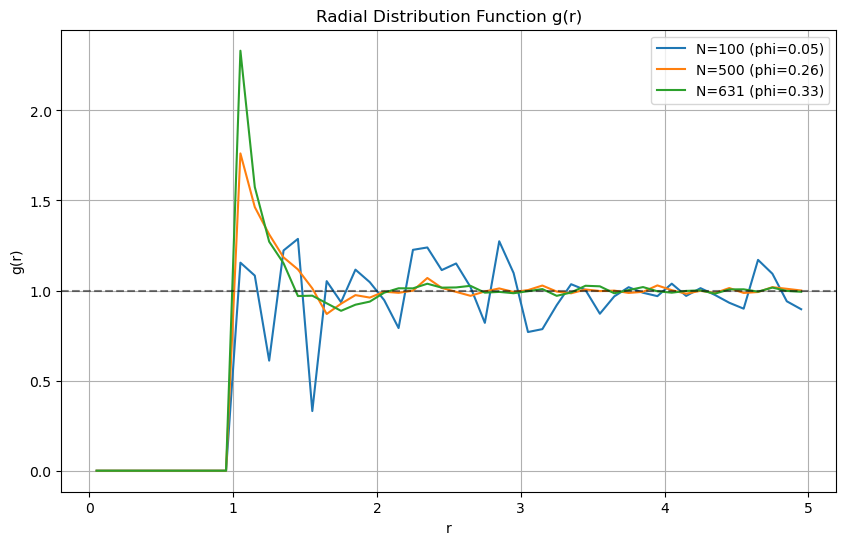

In [6]:
counts = [100, 500, 1000]
dr = 0.1
r_max = DOMAIN_SIZE / 2.0

plt.figure(figsize=(10, 6))

for N in counts:
    print(f"\n--- Processing N={N} ---")
    pos = generate_packing(N, DOMAIN_SIZE, RADIUS)
    actual_N = len(pos)
    density = (actual_N * (4/3) * np.pi * RADIUS**3) / DOMAIN_SIZE**3
    print(f"Generated {actual_N} particles. Packing Fraction: {density:.3f}")
    
    # Validate
    valid = validate_packing(pos, DOMAIN_SIZE, RADIUS)
    if not valid:
        print("WARNING: Invalid packing generated!")
    
    # RDF
    radii, g_r = compute_rdf(pos, DOMAIN_SIZE, r_max, dr)
    plt.plot(radii, g_r, label=f'N={actual_N} (phi={density:.2f})')

plt.axhline(1.0, color='k', linestyle='--', alpha=0.5)
plt.title("Radial Distribution Function g(r)")
plt.xlabel("r")
plt.ylabel("g(r)")
plt.legend()
plt.grid(True)
plt.show()